<a href="https://colab.research.google.com/github/alexandrufalk/tensorflow/blob/Master/Test_optical_param.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from google.colab import files

In [3]:

# Upload the file
uploaded = files.upload()

# Assuming the file is named 'optical_parameters_extended.csv'
file_name = 'optical_parameters_extended.csv'

# Load the CSV into a Pandas DataFrame
data = pd.read_csv(file_name)

# Display the first few rows of the DataFrame
print(data.head())


Saving optical_parameters_extended.csv to optical_parameters_extended.csv
   Distance (mm)       MTF  Distortion (%)  Vignetting (%)  \
0             10  0.790786        1.265387        0.671918   
1             10  0.753572        1.156102        0.678701   
2             10  0.734466        1.249757        0.723353   
3             10  0.678665        1.478042        0.901020   
4             10  0.654605        1.462927        1.288326   

   Chromatic Aberration (µm)  Contrast (%)  
0                   0.054279     69.484068  
1                   0.069293     68.054079  
2                   0.065235     65.453458  
3                   0.078031     64.399522  
4                   0.095808     62.220502  


In [4]:
# Step 2: Preprocess Data
# Handle missing values
data.dropna(inplace=True)

# Normalize data
data_normalized = (data - data.min()) / (data.max() - data.min())

# Convert units (e.g., mm to microns for precision)
data['Distance (mm)'] *= 1000  # Convert mm to microns

# Filter noise (example: low-pass filter for MTF data)
def low_pass_filter(data, cutoff, fs, order=2):
    b, a = butter(order, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, data)

fs = 1000  # Sampling frequency
fc = 50    # Cutoff frequency
data['MTF_filtered'] = low_pass_filter(data['MTF'], fc, fs)
print(data['MTF_filtered'])

0     0.789370
1     0.774285
2     0.760535
3     0.748894
4     0.739754
5     0.732999
6     0.728211
7     0.725058
8     0.723383
9     0.722972
10    0.723388
11    0.724152
12    0.725039
13    0.726100
14    0.727369
15    0.728628
16    0.729486
17    0.729706
18    0.729327
19    0.728476
20    0.727199
21    0.725521
22    0.723656
23    0.721997
24    0.720840
25    0.720152
26    0.719715
27    0.719510
28    0.719756
29    0.720565
30    0.721675
31    0.722637
32    0.723245
33    0.723667
34    0.724131
35    0.724619
36    0.724971
37    0.725178
38    0.725388
39    0.725656
40    0.725713
41    0.725035
42    0.723130
43    0.719616
44    0.714016
45    0.705626
46    0.693798
47    0.678432
48    0.660208
49    0.640456
Name: MTF_filtered, dtype: float64


In [5]:
# Step 3: Analyze Data
mean_mtf = data['MTF_filtered'].mean()
std_mtf = data['MTF_filtered'].std()
chromatic_range = data['Chromatic Aberration (µm)'].max() - data['Chromatic Aberration (µm)'].min()

print(mean_mtf)
print(std_mtf)
print(chromatic_range)

# MTF vs Spatial Frequency
spatial_frequencies = np.linspace(10, 100, len(data))  # Example spatial frequencies in lp/mm
data['Spatial_Frequency_lp_mm'] = spatial_frequencies
data['MTF_vs_Spatial_Frequency'] = data['MTF_filtered'] * np.exp(-spatial_frequencies / 50)  # Example relationship

print(data['MTF_vs_Spatial_Frequency'] )

0.7232648177831771
0.022063183708122533
0.071119184990799
0     0.646281
1     0.611066
2     0.578566
3     0.549162
4     0.522894
5     0.499432
6     0.478274
7     0.459027
8     0.441448
9     0.425284
10    0.410181
11    0.395804
12    0.381996
13    0.368756
14    0.356078
15    0.343828
16    0.331817
17    0.319946
18    0.308246
19    0.296781
20    0.285575
21    0.274640
22    0.264054
23    0.253946
24    0.244395
25    0.235355
26    0.226729
27    0.218488
28    0.210680
29    0.203310
30    0.196278
31    0.189451
32    0.182772
33    0.176282
34    0.170033
35    0.164011
36    0.158172
37    0.152510
38    0.147052
39    0.141801
40    0.136697
41    0.131644
42    0.126562
43    0.121404
44    0.116115
45    0.110612
46    0.104835
47    0.098815
48    0.092693
49    0.086676
Name: MTF_vs_Spatial_Frequency, dtype: float64


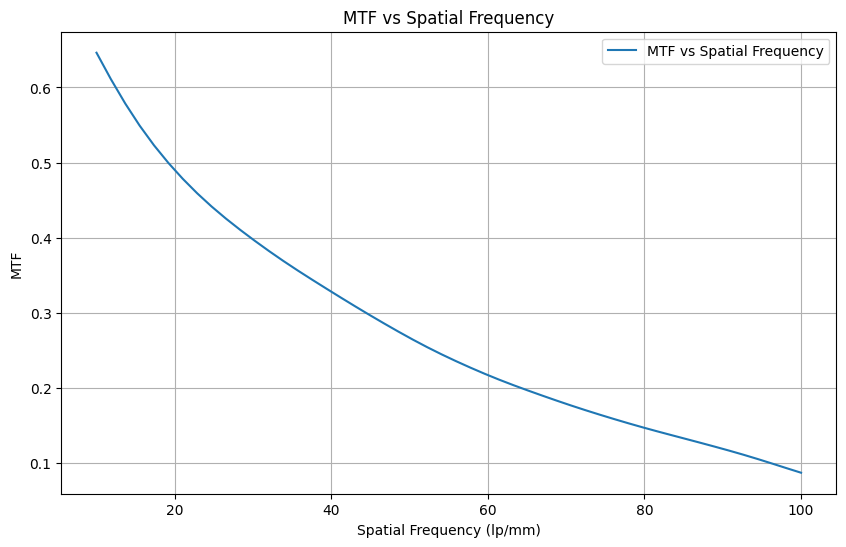

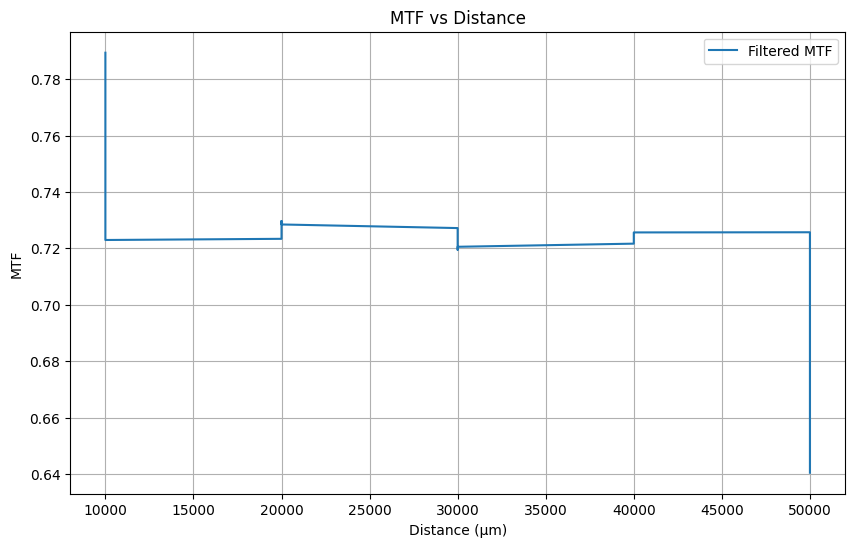

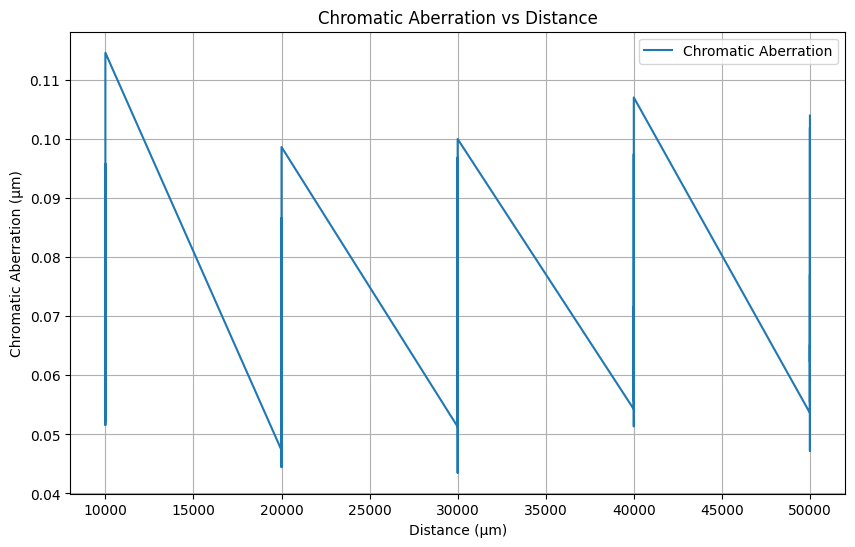

In [6]:
#Step 4: Visualize Data

plt.figure(figsize=(10, 6))
plt.plot(data['Spatial_Frequency_lp_mm'], data['MTF_vs_Spatial_Frequency'], label='MTF vs Spatial Frequency')
plt.title('MTF vs Spatial Frequency')
plt.xlabel('Spatial Frequency (lp/mm)')
plt.ylabel('MTF')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(data['Distance (mm)'], data['MTF_filtered'], label='Filtered MTF')
plt.title('MTF vs Distance')
plt.xlabel('Distance (μm)')
plt.ylabel('MTF')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(data['Distance (mm)'], data['Chromatic Aberration (µm)'], label='Chromatic Aberration')
plt.title('Chromatic Aberration vs Distance')
plt.xlabel('Distance (μm)')
plt.ylabel('Chromatic Aberration (µm)')
plt.grid(True)
plt.legend()
plt.show()
